# Combined Weather Data Exploration

This notebook loads `combined_test_clean_noheaders.csv` and plots all available parameters over time.

For each parameter you will get:
- A time-series plot
- A short, plain-language interpretation of what that parameter means

You can scroll through the plots to visually inspect patterns and anomalies across the full combined dataset.


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

CSV_PATH = Path("combined_test_clean_noheaders.csv")

COLUMNS = [
    "date (yyyy-MM-dd HH:mm:ss)",
    "windAlg.Spd_2m_kt",
    "windAlg.Dir_2m",
    "windAlg.GustAv_10m_kt",
    "windAlg.SpdX_2m_kt",
    "windAlg.Spd_10m_kt",
    "windAlg.Dir_10m",
    "windAlg.DirCCw_10m",
    "windAlg.DirCw_10m",
    "windAlg.Peak_10m_kt",
    "zenoAlg.AT_5m_C",
    "zenoAlg.DP_5m_C",
    "zenoAlg.RH_5m",
    "SR_6m_J/mncm2",
    "baroAlg.QNH_1m_mb",
    "baroAlg.QFE_1m_mb",
    "baroAlg.BPLow_1m_mb",
    "zenoAlg.PP_1h_mm",
    "zenoAlg.PP_6h_mm",
]

df = pd.read_csv(
    CSV_PATH,
    header=None,
    names=COLUMNS,
    parse_dates=["date (yyyy-MM-dd HH:mm:ss)"],
)
df = df.set_index("date (yyyy-MM-dd HH:mm:ss)").sort_index()

print("Data loaded:")
print(df.index.min(), "->", df.index.max())
print("Shape:", df.shape)

df.describe().T


Data loaded:
2022-09-01 12:12:47 -> date (yyyy-MM-dd HH:mm:ss)
Shape: (11577, 18)


C:\Users\alfar\AppData\Local\Temp\ipykernel_21652\530227961.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,count,unique,top,freq
windAlg.Spd_2m_kt,11577,191,9.0,201
windAlg.Dir_2m,11577,348,35,203
windAlg.GustAv_10m_kt,11577,202,20.3,234
windAlg.SpdX_2m_kt,11577,193,9.1,193
windAlg.Spd_10m_kt,11577,188,11.0,230
windAlg.Dir_10m,11577,341,38,254
windAlg.DirCCw_10m,11577,328,4.0,291
windAlg.DirCw_10m,11577,320,63.0,240
windAlg.Peak_10m_kt,11577,249,20.3,210
zenoAlg.AT_5m_C,11577,137,27.2,221


In [3]:
# Interval consistency check for combined_test_clean_noheaders
ts = pd.to_datetime(df.index, format="mixed", errors="coerce")
ts_valid = ts[ts.notna()]
diffs = ts_valid.to_series().diff().dropna()
diffs_sec = diffs.dt.total_seconds()

print("=== Interval consistency check ===")
print("Rows:", len(df))
print("Time range:", df.index.min(), "->", df.index.max())
print()
print("Interval (seconds) - value_counts (top 15):")
print(diffs_sec.value_counts().head(15))
print()
print("Unique intervals (seconds):", sorted(diffs_sec.unique()))
expected_sec = diffs_sec.mode().iloc[0]
gaps = diffs_sec[diffs_sec != expected_sec]
print()
print("Expected interval (mode):", expected_sec, "sec (", expected_sec / 60, "min )")
print("Rows with different interval:", len(gaps))
if len(gaps) > 0:
    print("Other intervals present:", gaps.value_counts().to_dict())
    print("Verdict: INTERVALS ARE NOT CONSISTENT")
else:
    print("Verdict: INTERVALS ARE CONSISTENT")

=== Interval consistency check ===
Rows: 11577
Time range: 2022-09-01 12:12:47 -> date (yyyy-MM-dd HH:mm:ss)

Interval (seconds) - value_counts (top 15):
date (yyyy-MM-dd HH:mm:ss)
60.0     7600
120.0     309
180.0     246
240.0     196
300.0     134
360.0      91
420.0      88
540.0      83
720.0      77
480.0      76
660.0      74
600.0      70
780.0      62
840.0      62
960.0      55
Name: count, dtype: int64

Unique intervals (seconds): [np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(120.0), np.float64(121.0), np.float64(122.0), np.float64(180.0), np.float64(240.0), np.float64(299.0), np.float64(300.0), np.float64(360.0), np.float64(420.0), np.float64(480.0), np.float64(540.0), np.float64(543.0), np.float64(600.0), np.float64(660.0), np.float64(663.0), np.float64(720.0), np.float64(722.0), np.float64(780.0), np.float64(840.0), np.float64(900.0), np.float64(960.0), np.float64(1020.0), np.float64(1023.0), np.float64(1080.0), np.float64(1140.0), np

In [4]:
# Create resampled CSV: 10-minute intervals
ts = pd.to_datetime(df.index, format="mixed", errors="coerce")
df_clean = df.loc[ts.notna()].copy()
df_clean.index = pd.DatetimeIndex(ts[ts.notna()])
df_clean = df_clean.sort_index()

# Ensure numeric columns
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Resample to 10-minute intervals (mean aggregation)
df_10min = df_clean.resample("10T").mean()

# Save to CSV (with header)
OUT_PATH = Path("combined_test_clean_10min.csv")
df_10min.to_csv(OUT_PATH, date_format="%Y-%m-%d %H:%M:%S")
print(f"Saved: {OUT_PATH}")
print(f"Rows: {len(df_10min)} (from {len(df_clean)} raw)")
print(f"Interval: 10 minutes")
print(f"Time range: {df_10min.index.min()} -> {df_10min.index.max()}")

C:\Users\alfar\AppData\Local\Temp\ipykernel_21652\3169425715.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_10min = df_clean.resample("10T").mean()


Saved: combined_test_clean_10min.csv
Rows: 184059 (from 11576 raw)
Interval: 10 minutes
Time range: 2022-09-01 12:10:00 -> 2026-03-02 16:30:00


In [5]:
# Create Excel: wind speed/direction -> U,V vector (meteorological convention)
import numpy as np

# Use raw data from combined_test_clean_noheaders.csv (no resampling)
wind_df = df[["windAlg.Spd_2m_kt", "windAlg.Dir_2m"]].copy()
wind_df = wind_df.dropna()
wind_df["Spd_kt"] = pd.to_numeric(wind_df["windAlg.Spd_2m_kt"], errors="coerce")
wind_df["Dir_deg"] = pd.to_numeric(wind_df["windAlg.Dir_2m"], errors="coerce")
wind_df = wind_df.dropna(subset=["Spd_kt", "Dir_deg"])

# Meteorological convention: direction FROM which wind blows (0=N, 90=E, 180=S, 270=W)
# U = eastward component (+ = from west), V = northward component (+ = from south)
dir_rad = np.radians(wind_df["Dir_deg"])
wind_df["U_kt"] = -wind_df["Spd_kt"] * np.sin(dir_rad)
wind_df["V_kt"] = -wind_df["Spd_kt"] * np.cos(dir_rad)

out = wind_df[["U_kt", "V_kt"]].rename(columns={"U_kt": "U (kt)", "V_kt": "V (kt)"})
OUT_CSV = Path("wind_uv.csv")
out.to_csv(OUT_CSV)
print(f"Saved: {OUT_CSV}")
print(f"Columns: U (kt), V (kt) | Rows: {len(out)}")

Saved: wind_uv.csv
Columns: U (kt), V (kt) | Rows: 11576


Parameter: windAlg.Spd_2m_kt
Meaning : Wind speed measured 2 m above ground in knots. Higher values mean stronger near-surface winds.



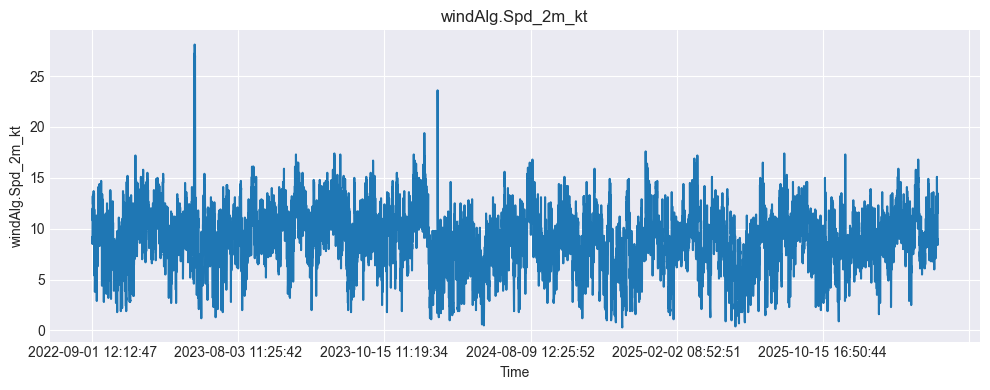

Parameter: windAlg.Dir_2m
Meaning : Wind direction at 2 m height in degrees (0–360). Shows where the wind is coming from near the surface.



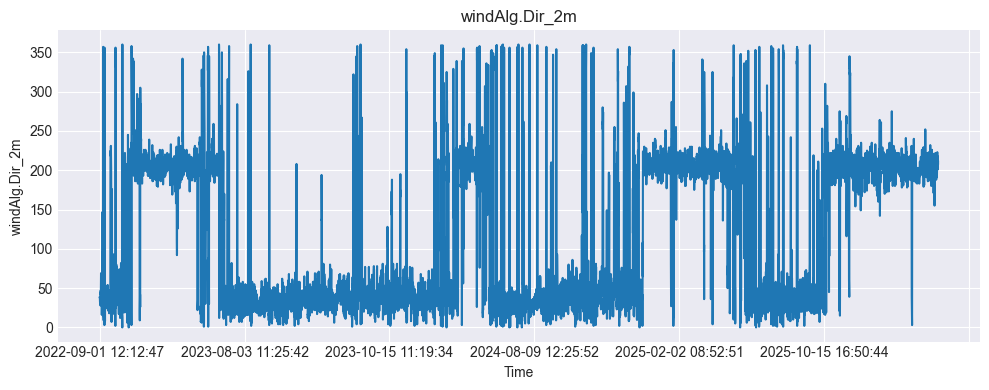

Parameter: windAlg.GustAv_10m_kt
Meaning : Average wind gust speed at 10 m height in knots. Highlights short, strong bursts of wind.



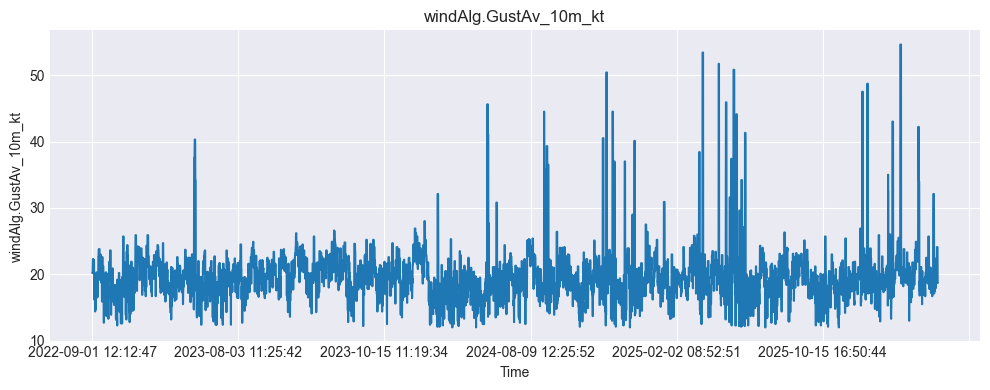

Parameter: windAlg.SpdX_2m_kt
Meaning : Maximum wind speed at 2 m in knots over the sampling interval.



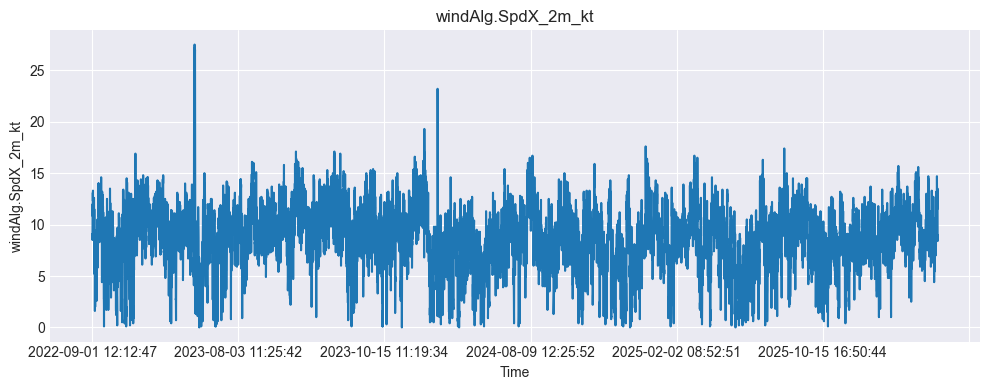

Parameter: windAlg.Spd_10m_kt
Meaning : Wind speed at 10 m height in knots. Common reference level for meteorological wind.



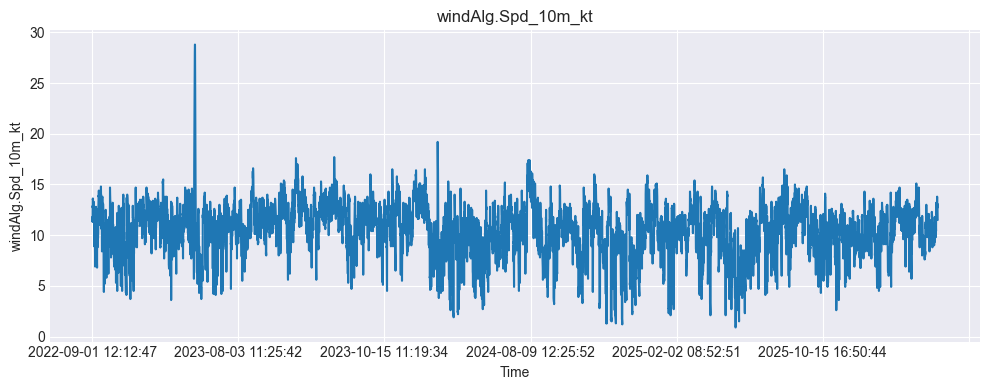

Parameter: windAlg.Dir_10m
Meaning : Wind direction at 10 m height in degrees. Used to study prevailing wind patterns.



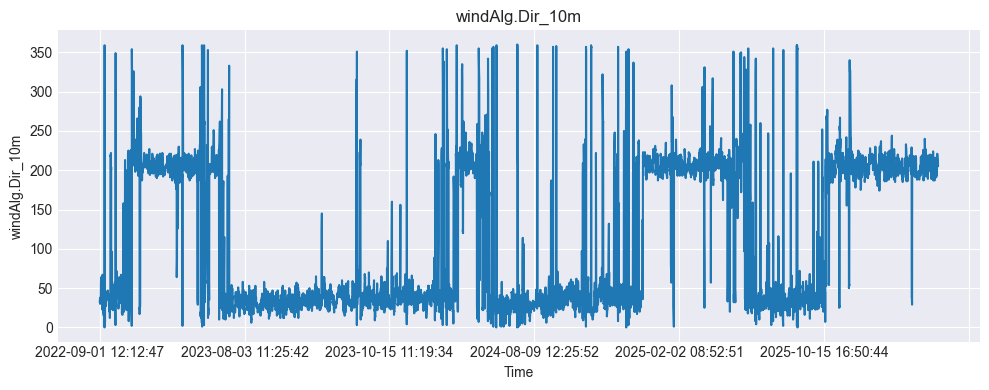

Parameter: windAlg.DirCCw_10m
Meaning : Counter-clockwise wind direction metric at 10 m (degrees). Useful for directional statistics.



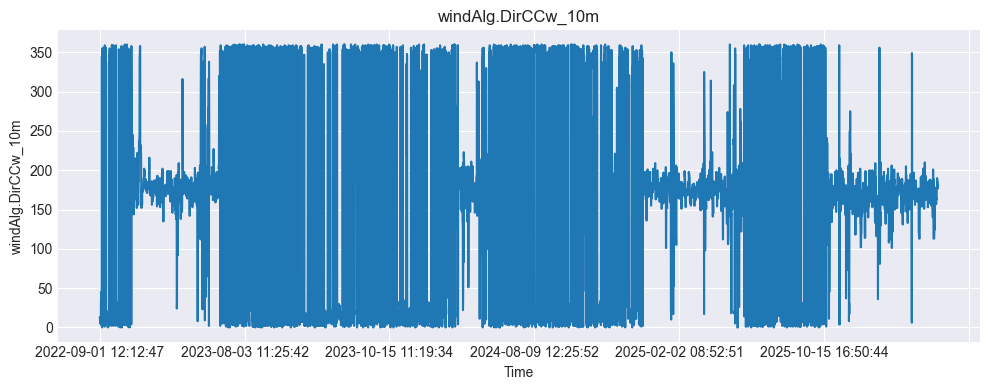

Parameter: windAlg.DirCw_10m
Meaning : Clockwise wind direction metric at 10 m (degrees). Complements DirCCw_10m.



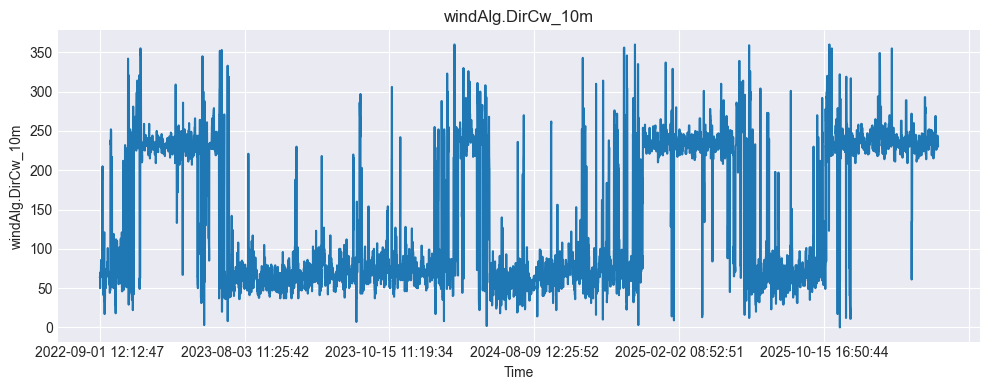

Parameter: windAlg.Peak_10m_kt
Meaning : Peak (maximum) wind speed at 10 m in knots within each interval.



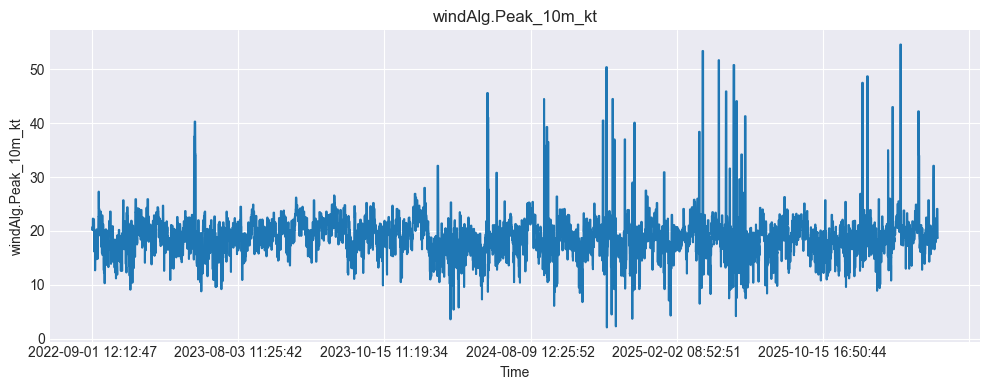

Parameter: zenoAlg.AT_5m_C
Meaning : Air temperature at 5 m in degrees Celsius. Shows heating/cooling over time.



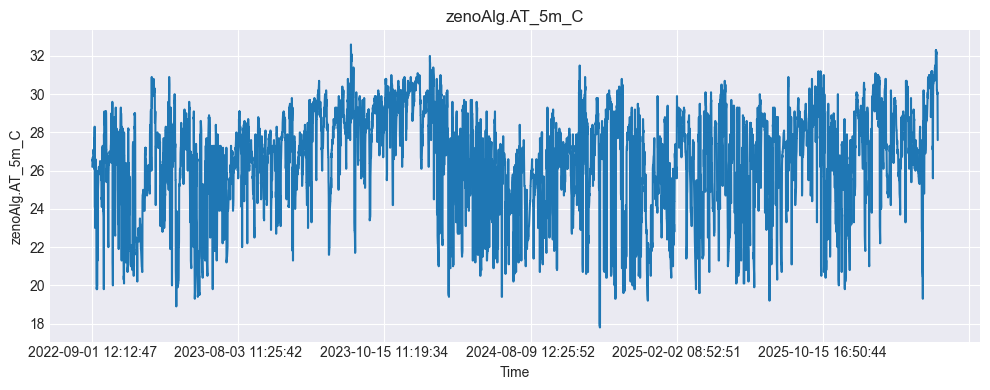

Parameter: zenoAlg.DP_5m_C
Meaning : Dew point temperature at 5 m in degrees Celsius. Closer to air temperature means higher humidity.



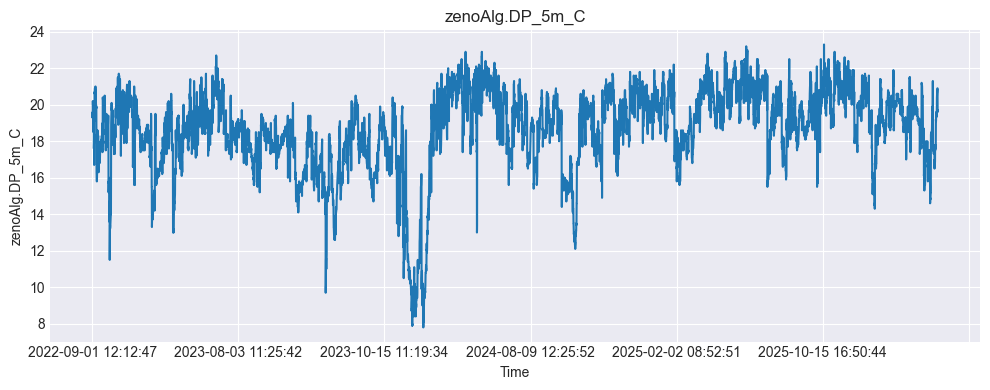

Parameter: zenoAlg.RH_5m
Meaning : Relative humidity at 5 m in percent. Near 100% indicates saturated, near 0% very dry air.



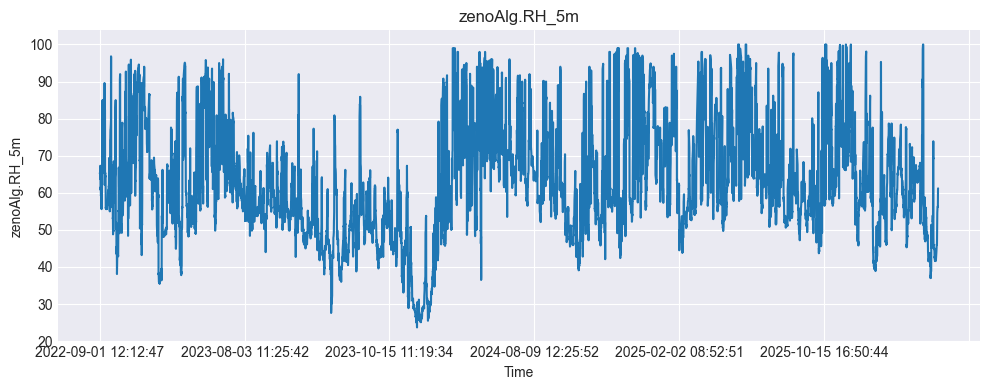

Parameter: SR_6m_J/mncm2
Meaning : Solar radiation at 6 m (energy per unit area). Higher midday values indicate strong sunlight.



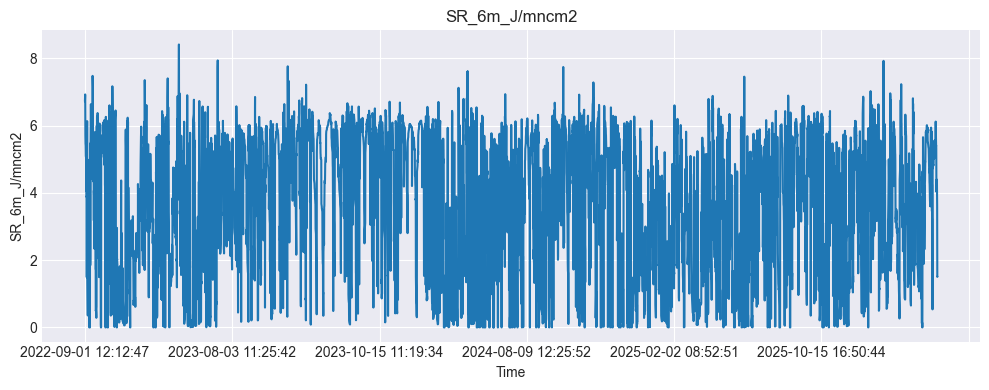

Parameter: baroAlg.QNH_1m_mb
Meaning : Sea-level adjusted pressure (QNH) in millibars. Used by aviation and for synoptic analysis.



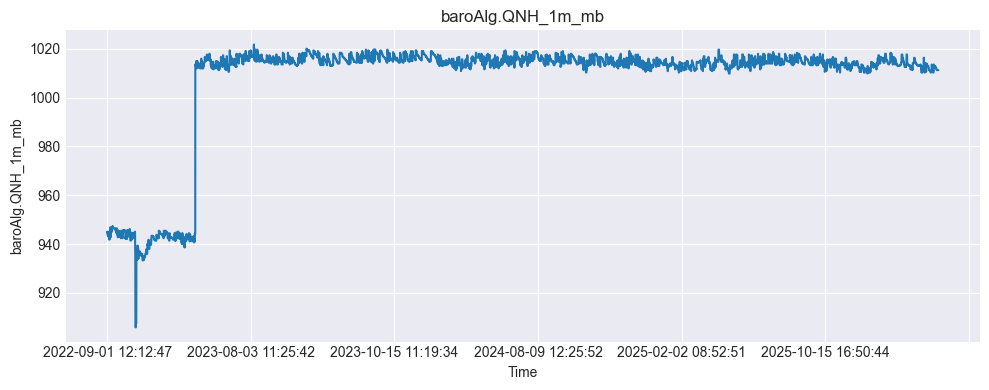

Parameter: baroAlg.QFE_1m_mb
Meaning : Station-level pressure (QFE) in millibars at the sensor site.



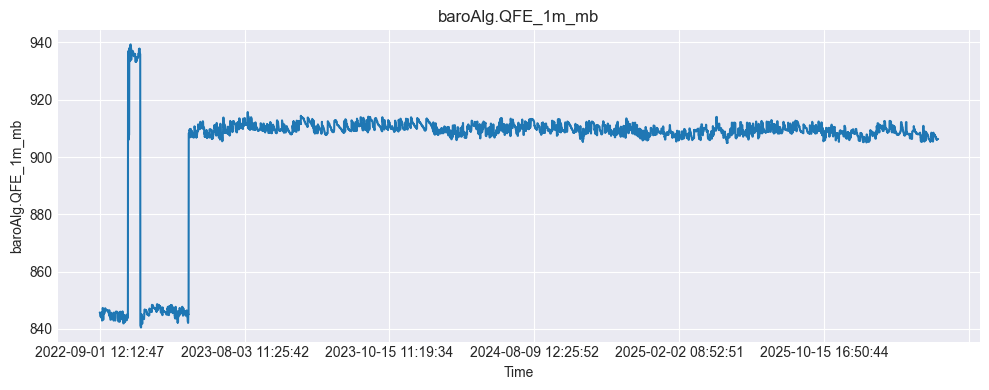

Parameter: baroAlg.BPLow_1m_mb
Meaning : Low-level barometric pressure in millibars; useful for tracking pressure systems.



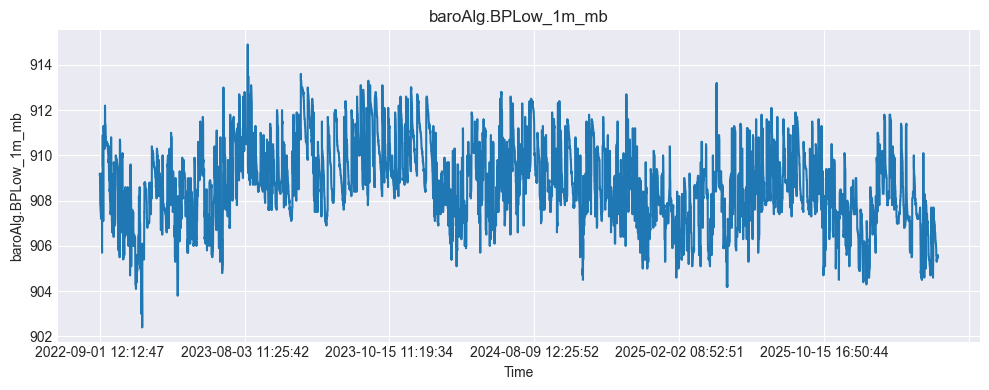

Parameter: zenoAlg.PP_1h_mm
Meaning : Precipitation accumulation over the last 1 hour in millimetres.



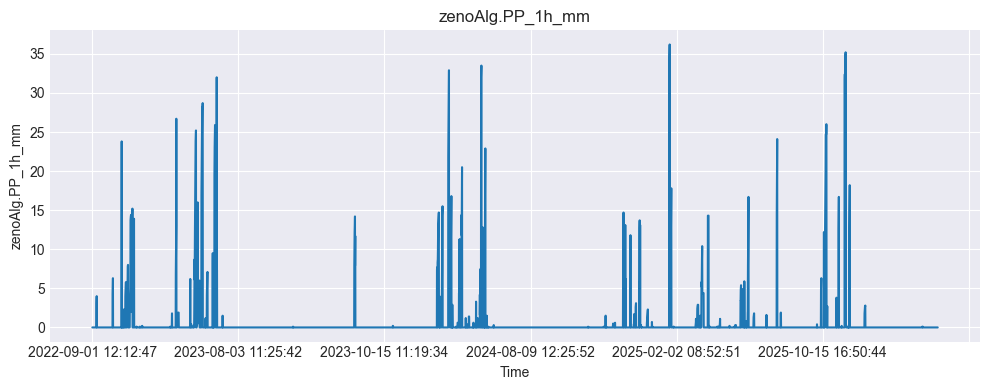

Parameter: zenoAlg.PP_6h_mm
Meaning : Precipitation accumulation over the last 6 hours in millimetres.



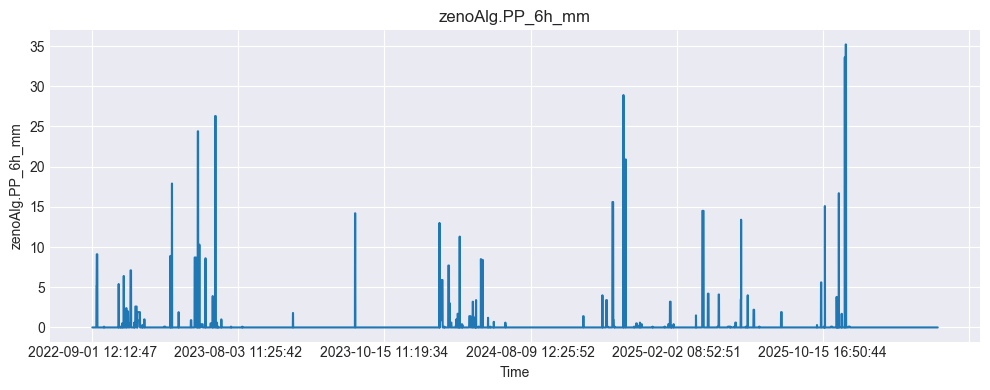

In [6]:
INTERPRETATIONS = {
    "windAlg.Spd_2m_kt": "Wind speed measured 2 m above ground in knots. Higher values mean stronger near-surface winds.",
    "windAlg.Dir_2m": "Wind direction at 2 m height in degrees (0–360). Shows where the wind is coming from near the surface.",
    "windAlg.GustAv_10m_kt": "Average wind gust speed at 10 m height in knots. Highlights short, strong bursts of wind.",
    "windAlg.SpdX_2m_kt": "Maximum wind speed at 2 m in knots over the sampling interval.",
    "windAlg.Spd_10m_kt": "Wind speed at 10 m height in knots. Common reference level for meteorological wind.",
    "windAlg.Dir_10m": "Wind direction at 10 m height in degrees. Used to study prevailing wind patterns.",
    "windAlg.DirCCw_10m": "Counter-clockwise wind direction metric at 10 m (degrees). Useful for directional statistics.",
    "windAlg.DirCw_10m": "Clockwise wind direction metric at 10 m (degrees). Complements DirCCw_10m.",
    "windAlg.Peak_10m_kt": "Peak (maximum) wind speed at 10 m in knots within each interval.",
    "zenoAlg.AT_5m_C": "Air temperature at 5 m in degrees Celsius. Shows heating/cooling over time.",
    "zenoAlg.DP_5m_C": "Dew point temperature at 5 m in degrees Celsius. Closer to air temperature means higher humidity.",
    "zenoAlg.RH_5m": "Relative humidity at 5 m in percent. Near 100% indicates saturated, near 0% very dry air.",
    "SR_6m_J/mncm2": "Solar radiation at 6 m (energy per unit area). Higher midday values indicate strong sunlight.",
    "baroAlg.QNH_1m_mb": "Sea-level adjusted pressure (QNH) in millibars. Used by aviation and for synoptic analysis.",
    "baroAlg.QFE_1m_mb": "Station-level pressure (QFE) in millibars at the sensor site.",
    "baroAlg.BPLow_1m_mb": "Low-level barometric pressure in millibars; useful for tracking pressure systems.",
    "zenoAlg.PP_1h_mm": "Precipitation accumulation over the last 1 hour in millimetres.",
    "zenoAlg.PP_6h_mm": "Precipitation accumulation over the last 6 hours in millimetres.",
}

for col in df.columns:
    print("=" * 80)
    print(f"Parameter: {col}")
    desc = INTERPRETATIONS.get(col, "No specific description available; inspect the units and range.")
    print("Meaning :", desc)
    print()

    # Ensure numeric series for plotting (handles string-typed numbers)
    series = pd.to_numeric(df[col], errors="coerce")
    if series.dropna().empty:
        print("Skipped: no numeric data to plot after conversion.")
        continue

    ax = series.plot(figsize=(10, 4))
    ax.set_title(col)
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
